1.3367674532736614e+29
533.3066609572703
18.57855411600078


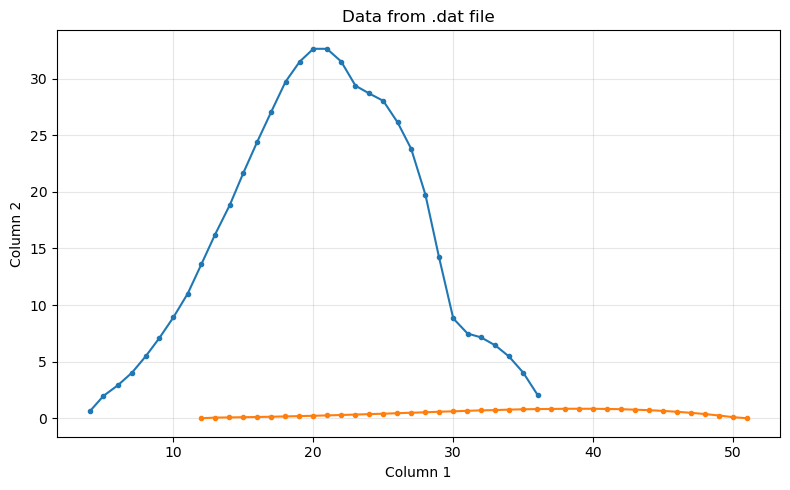

In [17]:
import numpy as np
import matplotlib.pyplot as plt


def get_data(path):
    # Read a plain-text .dat file (ignores lines starting with '#')
    data = np.genfromtxt(path, comments='#')
    # Ensure data is 2D and drop rows with NaNs
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    data = data[~np.isnan(data).any(axis=1)]
    if data.shape[1] < 2:
        raise ValueError('Expected at least two columns in the .dat file (x and y).')
    x = data[:, 0]
    y = data[:, 1]
    return x, y

cm_per_fm = 1e-13

kg_of_water = 4000
water_amu = 18.02
water_kg_per_amu = 1.66054e-27
water_atoms = kg_of_water/water_kg_per_amu/water_amu
print(water_atoms)

cm_per_fm = 1e-13

seconds_per_sns_year = 5000*60*60

nue_flux = 2.35e7

plt.figure(figsize=(8, 5))

path = '/nfs/disk1/users/bharris/NPA1038-electron_energy_xs_O16.dat'
x, y = get_data(path)
y = y*cm_per_fm**2*water_atoms*seconds_per_sns_year*nue_flux
print(np.sum(y))
plt.plot(x, y, marker='o', linestyle='-', markersize=3)

path = '/nfs/disk1/users/bharris/NPA1038-electron_energy_xs_O18.dat'
x, y = get_data(path)
y = (10**y)*cm_per_fm**2*water_atoms*seconds_per_sns_year*nue_flux
print(np.sum(y))
plt.plot(x, y, marker='o', linestyle='-', markersize=3)

plt.xlabel('Column 1')
plt.ylabel('Column 2')
plt.title('Data from .dat file')
plt.grid(True, alpha=0.3)
# plt.ylim(1e-44,1e-38)
# plt.ylim(1e-7,1e3)
plt.tight_layout()
# plt.yscale('log')
plt.show();




In [18]:
import numpy as np

print(np.array2string(x, separator=", ", formatter={'float_kind': lambda v: f"{v:.0f}"}))
# [1, 2, 3]

[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47,
 48, 49, 50, 51]


In [19]:
print(np.array2string(y, separator=', '))

[5.65452633e-82, 5.72123095e-02, 7.31897876e-02, 9.03923068e-02,
 1.11638033e-01, 1.34680929e-01, 1.62480150e-01, 1.89240555e-01,
 2.17838616e-01, 2.50758259e-01, 2.88652884e-01, 3.24570842e-01,
 3.64958415e-01, 4.00857936e-01, 4.45482695e-01, 4.89303071e-01,
 5.24974573e-01, 5.76613883e-01, 6.11437644e-01, 6.56012663e-01,
 6.95631599e-01, 7.20542042e-01, 7.64057647e-01, 7.91418922e-01,
 8.10201803e-01, 8.19759492e-01, 8.39214985e-01, 8.39214985e-01,
 8.39214985e-01, 8.19759492e-01, 8.00755036e-01, 7.55149393e-01,
 7.12141143e-01, 6.48364121e-01, 5.69891062e-01, 4.77959574e-01,
 3.69263949e-01, 2.42089092e-01, 9.36292392e-02, 5.65452633e-82]


In [16]:
import uproot as up
import awkward as ak

f = up.open('/nfs/disk1/users/bharris/eos/sim/EosSimulations/test_av.root')
output = f['output']

print(output.keys())

mcx = output['mcx'].array(library='ak')
mcy = output['mcy'].array(library='ak')
mcz = output['mcz'].array(library='ak')
nhits = output['nhits'].array()
charge = output['digitCharge'].array(library='ak')
xdir = output['u_fitdirectioncenter__5_quad'].array(library='ak')
wdir = output['w_fitdirectioncenter__5_quad'].array(library='ak')


import matplotlib.pyplot as plt


['mcpdg', 'mcx', 'mcy', 'mcz', 'mcu', 'mcv', 'mcw', 'mcke', 'mct', 'evid', 'subev', 'nhits', 'totalcharge', 'triggerTime', 'timestamp', 'trigger_word', 'event_cleaning_word', 'timeSinceLastTrigger_us', 'mcid', 'mcparticlecount', 'mcpecount', 'mcnhits', 'scintEdep', 'scintEdepQuenched', 'scintPhotons', 'remPhotons', 'cherPhotons', 'hitPMTID', 'hitPMTTime', 'hitPMTCharge', 'digitNhits', 'digitPMTID', 'digitTime', 'digitCharge', 'digitNCrossings', 'digitNhitsCleaned', 'digitHitCleaningMask', 'digitTimeOverThreshold', 'digitVoltageOverThreshold', 'digitPeak', 'digitLocalTriggerTime', 'digitReconNPEs', 'fit_pmtid_Lognormal', 'fit_time_Lognormal', 'fit_charge_Lognormal', 'fit_FOM_Lognormal_baseline', 'fit_FOM_Lognormal_chi2ndf', 'fit_pmtid_Gaussian', 'fit_time_Gaussian', 'fit_charge_Gaussian', 'fit_FOM_Gaussian_baseline', 'fit_FOM_Gaussian_width', 'fit_FOM_Gaussian_chi2ndf', 'fit_pmtid_Sinc', 'fit_time_Sinc', 'fit_charge_Sinc', 'fit_FOM_Sinc_peak', 'fit_pmtid_LucyDDM', 'fit_time_LucyDDM', 'f

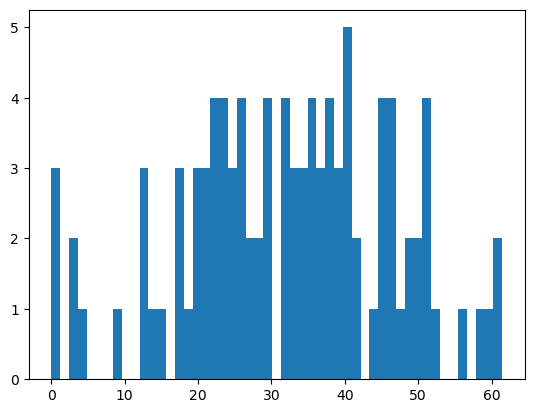

In [17]:
plt.hist(ak.sum(charge, axis=1)*.04,bins=51);

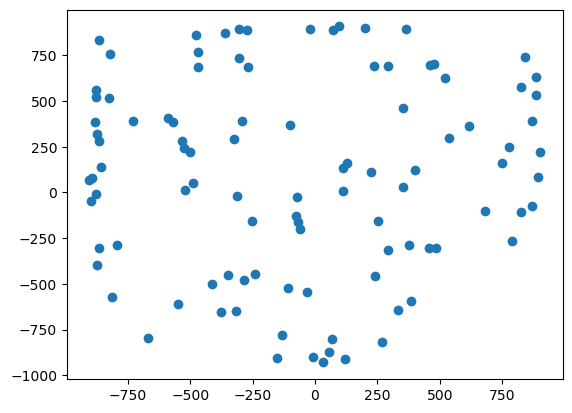

In [25]:
import numpy as np
plt.scatter(mcx,mcz);


In [15]:
path = '/nfs/disk1/users/bharris/sns-nue-beam-timing.dat'
x, y = get_data(path)

# Ensure x is sorted for interpolation/integration
order = np.argsort(x)
x = x[order]
y = y[order]

# Interpolate onto a dense grid, then integrate
x_interp = np.linspace(x.min(), x.max(), 2000)
y_interp = np.interp(x_interp, x, y)

cut = 1

area_total = np.trapz(y_interp, x_interp)
if cut <= x_interp.min():
    area_after = area_total
elif cut >= x_interp.max():
    area_after = 0.0
else:
    mask_after = x_interp >= cut
    area_after = np.trapz(y_interp[mask_after], x_interp[mask_after])

percent_after = 100.0 * area_after / area_total
print(f"Area after x={cut}: {percent_after:.2f}%")

plt.plot(x, y, 'o', ms=3, label='data')
plt.plot(x_interp, y_interp, '-', lw=2, label='linear interpolation')
plt.axvline(cut, color='r', ls='--', label=f'cut={cut}')
plt.ylim(0, 1)
plt.legend()
plt.show()


NameError: name 'get_data' is not defined